# EDA 01 - labelled_jobids.csv

Notebook nay phan tich file nhan model theo id_job va kiem tra relationship voi slurm-log.csv.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

In [2]:
DATA_DIR = Path('..') / 'data'
label_path = DATA_DIR / 'labelled_jobids.csv'
slurm_path = DATA_DIR / 'slurm-log.csv'

labels = pd.read_csv(label_path, dtype={'id_job': 'string', 'model': 'string'})
slurm = pd.read_csv(slurm_path, dtype={'id_job': 'string'})

print('labels shape:', labels.shape)
print('slurm shape :', slurm.shape)

labels shape: (3430, 2)
slurm shape : (395914, 29)


## 1) Kiem tra tong quan va chat luong du lieu nhan

In [3]:
display(labels.head())
display(labels.sample(5, random_state=42))

summary = pd.DataFrame({
    'dtype': labels.dtypes.astype(str),
    'null_count': labels.isna().sum(),
    'null_ratio': labels.isna().mean().round(4),
    'n_unique': labels.nunique(dropna=True)
})
display(summary)

,id_job,model
0,25664193915111,dimenet
1,42371679622969,schnet
2,64971010680493,conv
3,75737118513639,pna
4,68345852389234,dimenet


,id_job,model
679,20543835849950,vgg19
2063,24068217500970,U3-32
929,22511865878392,U3-64
2805,18308760986239,resnet50_v1.5
2119,64945746264753,U5-64


,dtype,null_count,null_ratio,n_unique
id_job,string,0,0.0,3430
model,string,0,0.0,26


In [4]:
dup_job_count = labels.duplicated(subset=['id_job']).sum()
dup_full_count = labels.duplicated().sum()

print('Duplicate id_job rows :', dup_job_count)
print('Duplicate full rows   :', dup_full_count)

if dup_job_count > 0:
    display(labels[labels.duplicated(subset=['id_job'], keep=False)].sort_values('id_job').head(20))

Duplicate id_job rows : 0
Duplicate full rows   : 0


## 2) Phan bo model trong tap nhan

,count,percent
model,,
inception4,243,7.08
inception3,241,7.03
vgg19,199,5.8
bert-base-uncased,189,5.51
vgg11,185,5.39
vgg16,176,5.13
distilbert-base-uncased,172,5.01
U3-128,165,4.81
U3-32,165,4.81


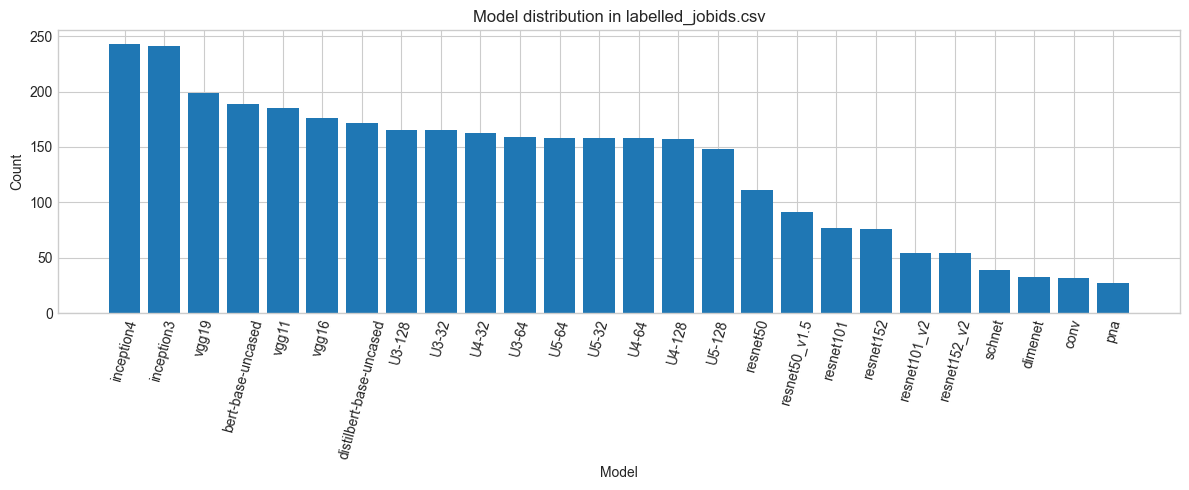

In [5]:
model_counts = labels['model'].value_counts(dropna=False)
model_ratio = labels['model'].value_counts(normalize=True, dropna=False).mul(100).round(2)
dist = pd.concat([model_counts.rename('count'), model_ratio.rename('percent')], axis=1)
display(dist)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(model_counts.index.astype(str), model_counts.values)
ax.set_title('Model distribution in labelled_jobids.csv')
ax.set_xlabel('Model')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

## 3) Relationship voi slurm-log.csv

In [6]:
slurm_id = slurm[['id_job']].dropna().drop_duplicates()
labels_merge = labels.merge(slurm_id.assign(in_slurm=1), on='id_job', how='left')
labels_merge['in_slurm'] = labels_merge['in_slurm'].fillna(0).astype(int)

coverage = labels_merge['in_slurm'].value_counts().rename(index={1: 'matched', 0: 'unmatched'}).to_frame('count')
coverage['ratio_percent'] = (coverage['count'] / len(labels_merge) * 100).round(2)
display(coverage)

model_coverage = labels_merge.groupby('model')['in_slurm'].agg(['count', 'sum'])
model_coverage = model_coverage.rename(columns={'sum': 'matched'})
model_coverage['coverage_percent'] = (model_coverage['matched'] / model_coverage['count'] * 100).round(2)
display(model_coverage.sort_values('coverage_percent'))

,count,ratio_percent
in_slurm,,
matched,3430,100.0


,count,matched,coverage_percent
model,,,
U3-128,165,165,100.0
vgg11,185,185,100.0
schnet,39,39,100.0
resnet50_v1.5,91,91,100.0
resnet50,111,111,100.0
resnet152_v2,54,54,100.0
resnet152,76,76,100.0
resnet101_v2,54,54,100.0
resnet101,77,77,100.0


In [7]:
unmatched = labels_merge.loc[labels_merge['in_slurm'] == 0, ['id_job', 'model']]
print('Unmatched label rows:', len(unmatched))
display(unmatched.head(20))

Unmatched label rows: 0


,id_job,model


## 4) Kiem tra cardinality khoa join

In [8]:
labels_unique_jobs = labels['id_job'].nunique(dropna=True)
slurm_unique_jobs = slurm['id_job'].nunique(dropna=True)

join_check = labels.merge(slurm[['id_job']], on='id_job', how='inner')
joined_unique_jobs = join_check['id_job'].nunique(dropna=True)

print('Unique id_job in labels:', labels_unique_jobs)
print('Unique id_job in slurm :', slurm_unique_jobs)
print('Unique id_job in inner join:', joined_unique_jobs)

slurm_multiplicity = slurm.groupby('id_job').size()
print('Median rows per id_job in slurm:', int(slurm_multiplicity.median()))
print('95th percentile rows per id_job:', int(slurm_multiplicity.quantile(0.95)))
print('Max rows per id_job in slurm:', int(slurm_multiplicity.max()))

Unique id_job in labels: 3430
Unique id_job in slurm : 395914
Unique id_job in inner join: 3430
Median rows per id_job in slurm: 1
95th percentile rows per id_job: 1
Max rows per id_job in slurm: 1


## 5) Ket luan nhanh

- `id_job` la khoa de noi 2 file.
- Muc do match cua labels voi slurm cho biet do day du cua metadata train.
- Notebook tiep theo (`02_eda_slurm_log_relationship.ipynb`) se dao sau vao metric runtime, state, partition theo tung model.